# DATA PREPROCESSING AND EDA


### Necessary Imports

In [1]:
# Core
import os
import shutil
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score

# XGBoost
from xgboost import XGBRegressor

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Torchvision
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights

# Image handling
from PIL import Image

# Utilities
from tqdm import tqdm


### Directories 

In [2]:
# Tabular data
train_df = pd.read_csv("/kaggle/input/plotprices/train(1)(train(1)).csv")
test_df  = pd.read_csv("/kaggle/input/plotprices/test2(test(1)).csv")

# Fused datasets (already contain image embeddings)
train_mm = pd.read_csv("/kaggle/input/fuseddata/train_image_embeddings.csv")
test_mm  = pd.read_csv("/kaggle/input/fuseddata/test_image_embeddings.csv")

print(train_df.shape, test_df.shape)
print(train_mm.shape, test_mm.shape)


(16209, 21) (5404, 20)
(16110, 513) (5396, 513)


### BASIC DATA INFO & STATISTICS

In [3]:
# ---- Dataset shape ----
print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

# ---- Preview ----
display(train_df.head())

# ---- Data types & null counts ----
print("\n--- DATA INFO ---")
train_df.info()

# ---- Separate numeric & categorical features ----
numeric_features = train_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [
    c for c in train_df.columns
    if c not in numeric_features
]

print("\nNumeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

# ---- Descriptive statistics (numeric only) ----
stats = train_df[numeric_features].describe().T
stats["skew"] = train_df[numeric_features].skew()
stats["kurtosis"] = train_df[numeric_features].kurtosis()

display(stats)

# ---- Unique values per column ----
print("\n--- UNIQUE VALUE COUNTS ---")
display(train_df.nunique().sort_values())

# ---- Target summary ----
if "price" in train_df.columns:
    display(pd.DataFrame({
        "price_raw": train_df["price"].describe(),
        "price_log": np.log1p(train_df["price"]).describe()
    }))


Train shape: (16209, 21)
Test shape : (5404, 20)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,9117000170,20150505T000000,268643,4,2.25,1810,9240,2.0,0,0,...,7,1810,0,1961,0,98055,47.4362,-122.187,1660,9240
1,6700390210,20140708T000000,245000,3,2.50,1600,2788,2.0,0,0,...,7,1600,0,1992,0,98031,47.4034,-122.187,1720,3605
2,7212660540,20150115T000000,200000,4,2.50,1720,8638,2.0,0,0,...,8,1720,0,1994,0,98003,47.2704,-122.313,1870,7455
3,8562780200,20150427T000000,352499,2,2.25,1240,705,2.0,0,0,...,7,1150,90,2009,0,98027,47.5321,-122.073,1240,750
4,7760400350,20141205T000000,232000,3,2.00,1280,13356,1.0,0,0,...,7,1280,0,1994,0,98042,47.3715,-122.074,1590,8071



--- DATA INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16209 entries, 0 to 16208
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             16209 non-null  int64  
 1   date           16209 non-null  object 
 2   price          16209 non-null  int64  
 3   bedrooms       16209 non-null  int64  
 4   bathrooms      16209 non-null  float64
 5   sqft_living    16209 non-null  int64  
 6   sqft_lot       16209 non-null  int64  
 7   floors         16209 non-null  float64
 8   waterfront     16209 non-null  int64  
 9   view           16209 non-null  int64  
 10  condition      16209 non-null  int64  
 11  grade          16209 non-null  int64  
 12  sqft_above     16209 non-null  int64  
 13  sqft_basement  16209 non-null  int64  
 14  yr_built       16209 non-null  int64  
 15  yr_renovated   16209 non-null  int64  
 16  zipcode        16209 non-null  int64  
 17  lat            16209 non-null  

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
id,16209.0,4.575771e+09,2.874661e+09,1.000102e+06,2.123049e+09,3.904950e+09,7.304301e+09,9.900000e+09,0.242147,-1.256555
price,16209.0,5.374703e+05,3.603036e+05,7.500000e+04,3.200000e+05,4.500000e+05,6.400000e+05,7.700000e+06,4.033062,37.106004
bedrooms,16209.0,3.367820e+00,9.332701e-01,0.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01,2.419404,63.747881
bathrooms,16209.0,2.113054e+00,7.652419e-01,0.000000e+00,1.500000e+00,2.250000e+00,2.500000e+00,8.000000e+00,0.461525,1.003859
sqft_living,16209.0,2.073275e+03,9.070095e+02,2.900000e+02,1.430000e+03,1.910000e+03,2.550000e+03,1.205000e+04,1.378761,4.257313
sqft_lot,16209.0,1.486767e+04,3.882570e+04,5.200000e+02,5.004000e+03,7.599000e+03,1.063100e+04,1.164794e+06,11.407202,209.173589
floors,16209.0,1.498828e+00,5.430321e-01,1.000000e+00,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00,0.615319,-0.480398
waterfront,16209.0,6.971436e-03,8.320614e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,11.852236,138.492586
view,16209.0,2.342526e-01,7.631515e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00,3.386537,10.856426
condition,16209.0,3.407860e+00,6.515529e-01,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00,1.027151,0.552089



--- UNIQUE VALUE COUNTS ---


waterfront           2
view                 5
condition            5
floors               6
grade               12
bedrooms            12
bathrooms           29
yr_renovated        69
zipcode             70
yr_built           116
sqft_basement      280
date               366
sqft_living15      692
long               708
sqft_above         803
sqft_living        881
price             3428
lat               4775
sqft_lot15        7279
sqft_lot          8048
id               16110
dtype: int64

,price_raw,price_log
count,1.620900e+04,16209.000000
mean,5.374703e+05,13.045201
std,3.603036e+05,0.523880
min,7.500000e+04,11.225257
25%,3.200000e+05,12.676079
50%,4.500000e+05,13.017005
75%,6.400000e+05,13.369225
max,7.700000e+06,15.856731


### Price-Distribution analysis

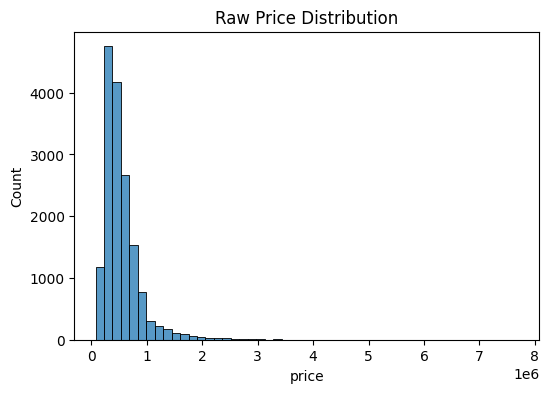

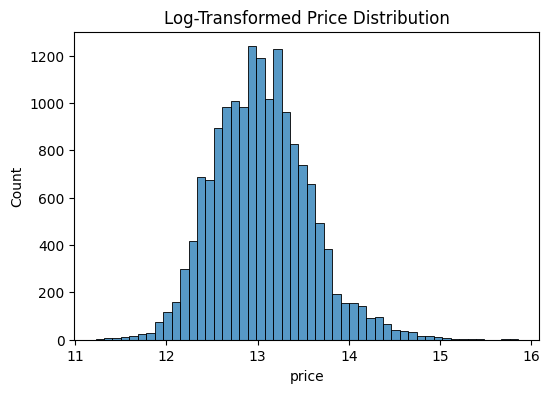

In [4]:
plt.figure(figsize=(6,4))
sns.histplot(train_df["price"], bins=50)
plt.title("Raw Price Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(np.log1p(train_df["price"]), bins=50)
plt.title("Log-Transformed Price Distribution")
plt.show()


### Feature Corelation

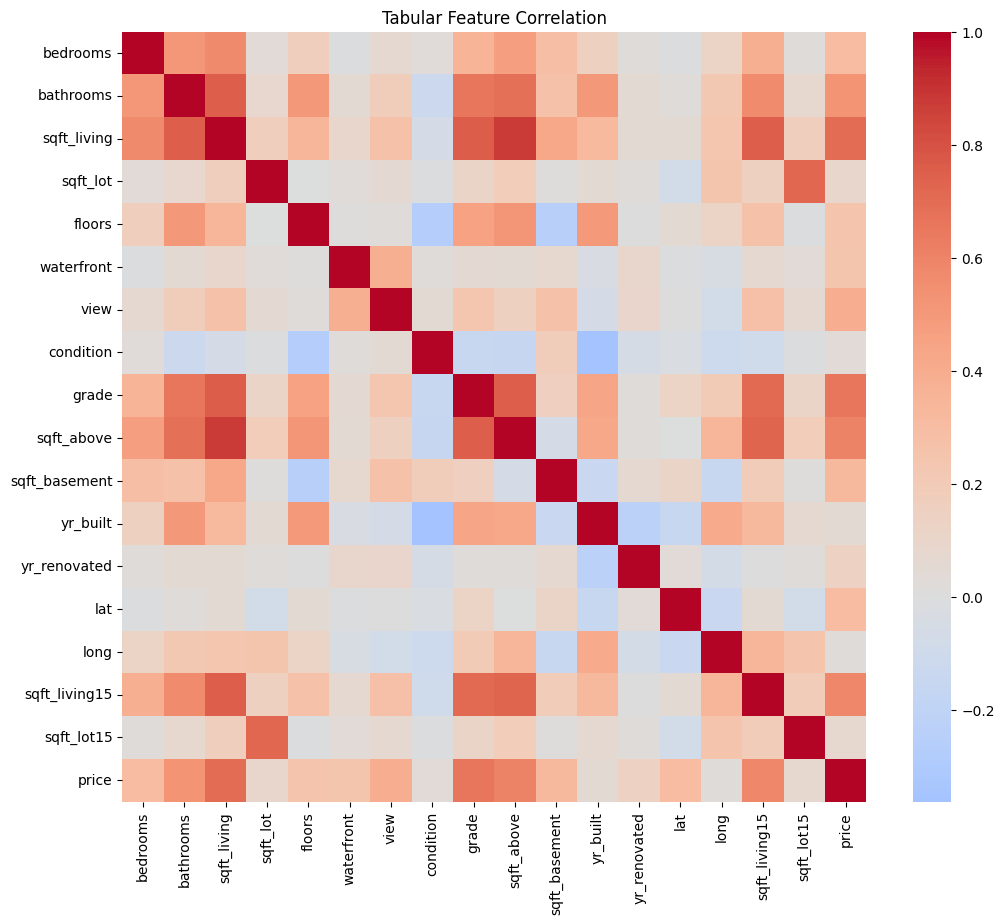

In [5]:
tabular_features = [
    'bedrooms','bathrooms','sqft_living','sqft_lot','floors',
    'waterfront','view','condition','grade',
    'sqft_above','sqft_basement',
    'yr_built','yr_renovated',
    'lat','long',
    'sqft_living15','sqft_lot15'
]

plt.figure(figsize=(12,10))
sns.heatmap(
    train_df[tabular_features + ["price"]].corr(),
    cmap="coolwarm", center=0
)
plt.title("Tabular Feature Correlation")
plt.show()


### Scatter-plot 

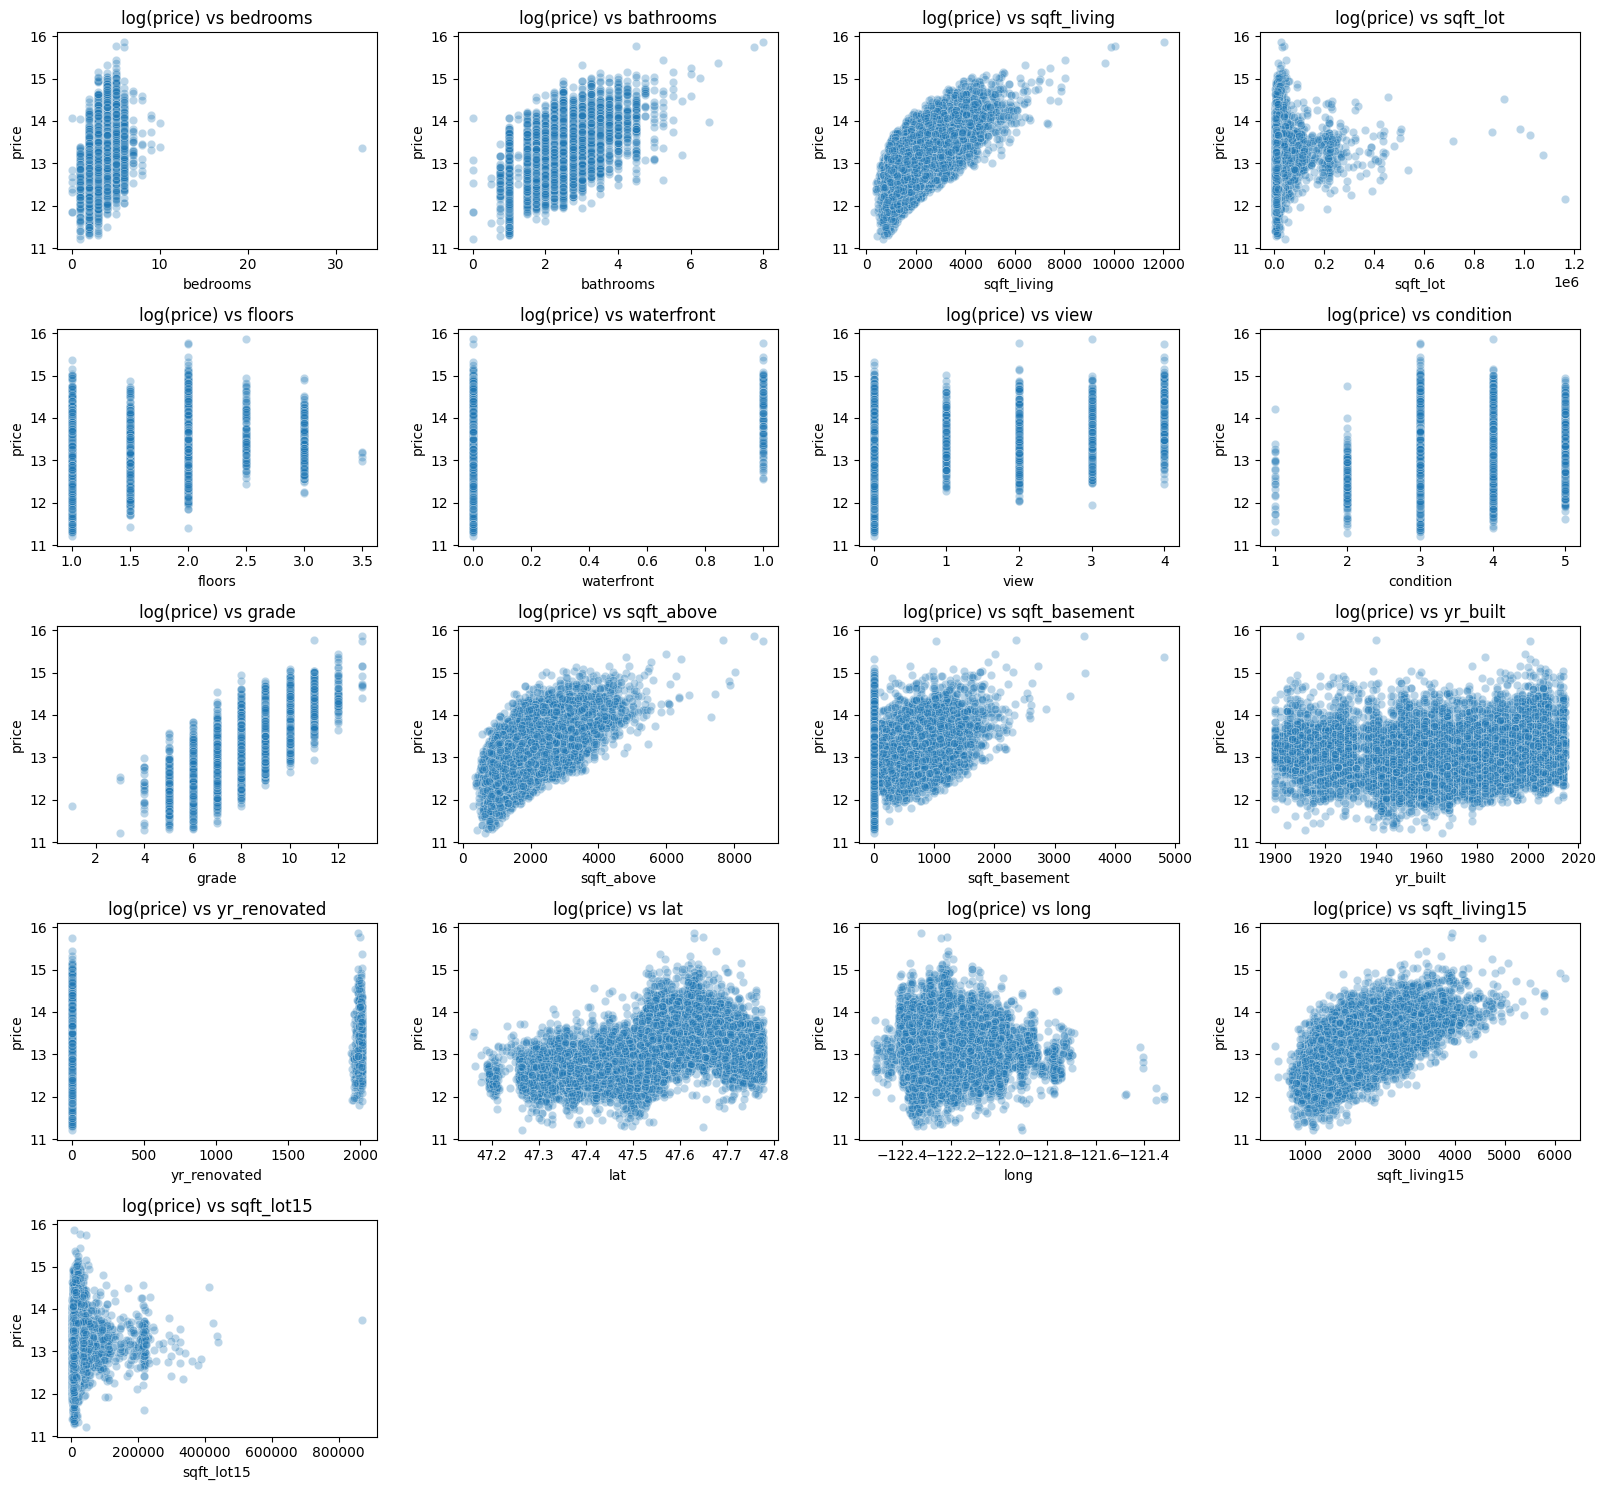

In [6]:
all_feats = [
    'bedrooms','bathrooms','sqft_living','sqft_lot','floors',
    'waterfront','view','condition','grade',
    'sqft_above','sqft_basement',
    'yr_built','yr_renovated',
    'lat','long',
    'sqft_living15','sqft_lot15'
]

n_feats = len(all_feats)
cols = 4
rows = int(np.ceil(n_feats / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3))
axes = axes.ravel()

for i, col in enumerate(all_feats):
    sns.scatterplot(
        x=train_df[col],
        y=np.log1p(train_df["price"]),
        ax=axes[i],
        alpha=0.3
    )
    axes[i].set_title(f"log(price) vs {col}")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Box-Plot

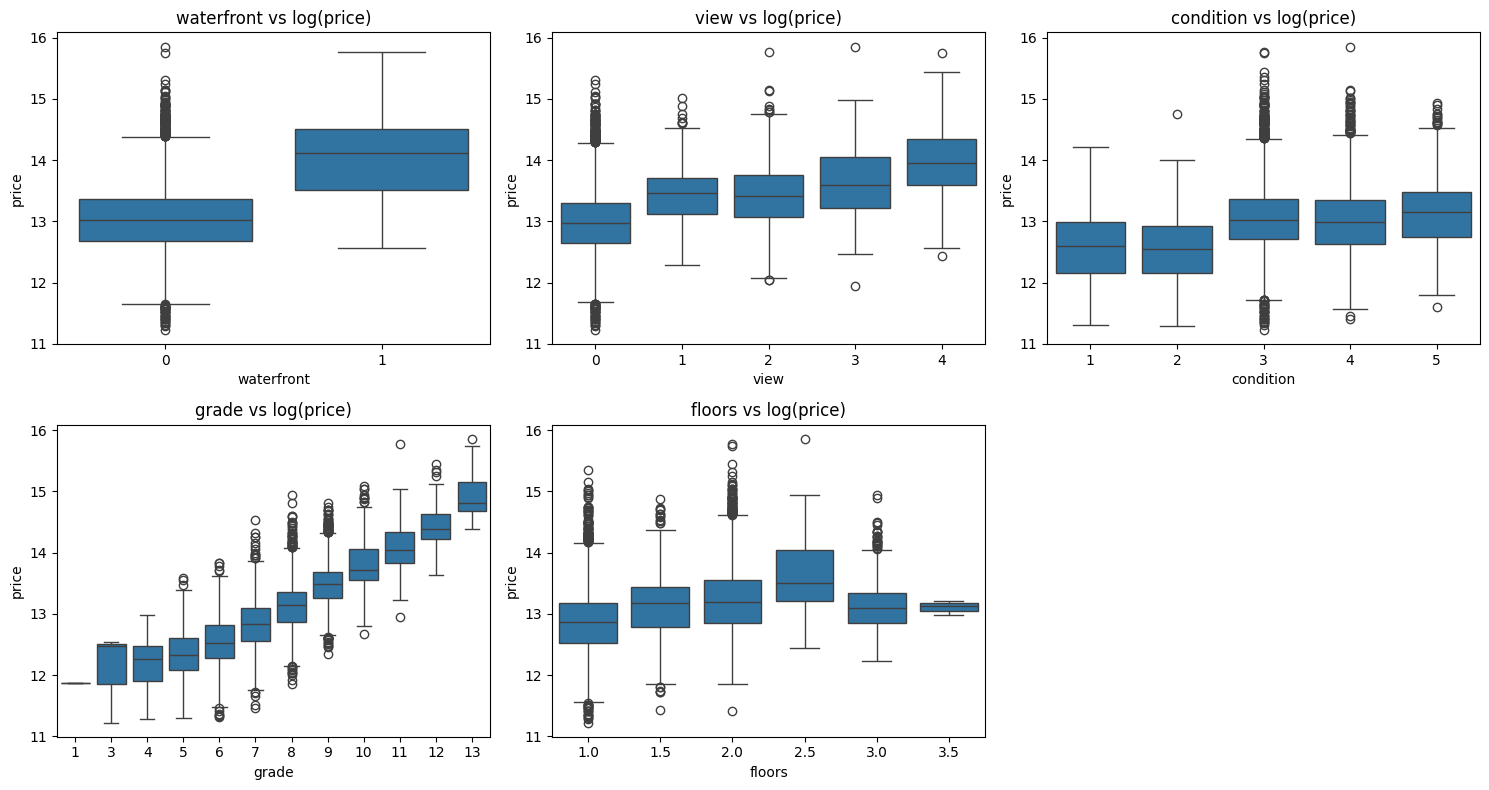

In [7]:
cat_feats = [
    "waterfront",
    "view",
    "condition",
    "grade",
    "floors"
]

n_feats = len(cat_feats)
cols = 3
rows = int(np.ceil(n_feats / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*4))
axes = axes.ravel()

for i, col in enumerate(cat_feats):
    sns.boxplot(
        x=train_df[col],
        y=np.log1p(train_df["price"]),
        ax=axes[i]
    )
    axes[i].set_title(f"{col} vs log(price)")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Image Embedding Variance Analysis

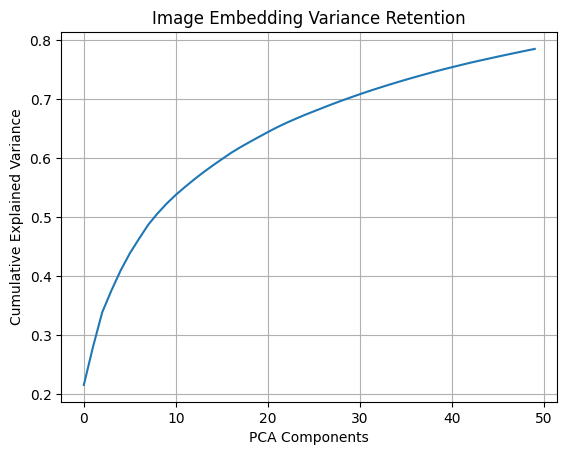

In [8]:
img_cols = [str(i) for i in range(512)]

pca_tmp = PCA(n_components=50)
pca_tmp.fit(train_mm[img_cols])

plt.plot(np.cumsum(pca_tmp.explained_variance_ratio_))
plt.xlabel("PCA Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Image Embedding Variance Retention")
plt.grid()
plt.show()


### Geospatial Price Heatmap

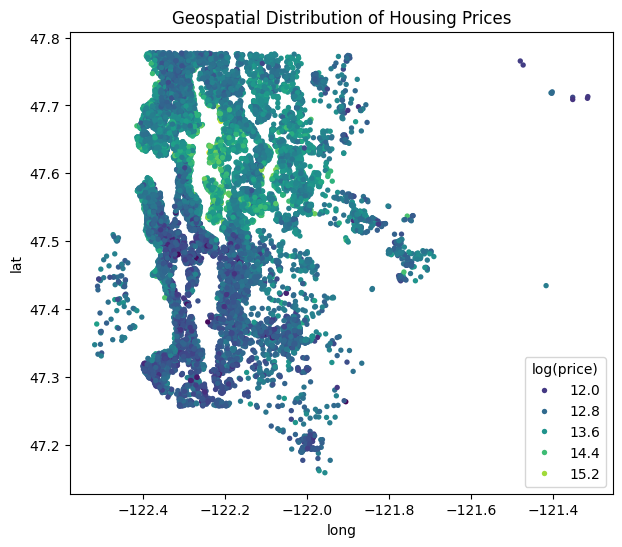

In [9]:
plt.figure(figsize=(7,6))
sns.scatterplot(
    x=train_df["long"],
    y=train_df["lat"],
    hue=np.log1p(train_df["price"]),
    palette="viridis",
    s=15,
    linewidth=0
)
plt.title("Geospatial Distribution of Housing Prices")
plt.legend(title="log(price)")
plt.show()


## Feature extraction & fusion 

#### EXTRACTON 

In [10]:
TRAIN_IMG_DIR = "/kaggle/input/downloadedimages/train"
TEST_IMG_DIR  = "/kaggle/input/downloadedimages/test"

BATCH_SIZE = 32
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


class SatelliteImageDataset(Dataset):
    def __init__(self, image_dir, transform):
        self.image_dir = image_dir
        self.transform = transform
        self.image_files = sorted(os.listdir(image_dir))

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.image_dir, img_name)

        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)

        house_id = int(img_name.replace(".png", ""))

        return image, house_id

train_ds = SatelliteImageDataset(TRAIN_IMG_DIR, image_transform)
test_ds  = SatelliteImageDataset(TEST_IMG_DIR, image_transform)


train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)


resnet = models.resnet18(pretrained=True)
resnet.fc = nn.Identity()

for param in resnet.parameters():
    param.requires_grad = False

resnet = resnet.to(DEVICE)
resnet.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 178MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [11]:
def extract_embeddings(model, dataloader):
    embeddings = {}

    with torch.no_grad():
        for images, ids in tqdm(dataloader):
            images = images.to(DEVICE)
            feats = model(images).cpu().numpy()

            for i, house_id in enumerate(ids):
                embeddings[int(house_id)] = feats[i]

    return embeddings

train_embeddings = extract_embeddings(resnet, train_loader)
test_embeddings  = extract_embeddings(resnet, test_loader)

print(len(train_embeddings), len(test_embeddings))



train_embed_df = pd.DataFrame.from_dict(
    train_embeddings, orient="index"
)
train_embed_df.index.name = "id"
train_embed_df.reset_index(inplace=True)

test_embed_df = pd.DataFrame.from_dict(
    test_embeddings, orient="index"
)
test_embed_df.index.name = "id"
test_embed_df.reset_index(inplace=True)

train_embed_df.to_csv("train_image_embeddings.csv", index=False)
test_embed_df.to_csv("test_image_embeddings.csv", index=False)

100%|██████████| 169/169 [00:44<00:00,  3.82it/s]


16110 5396


#### Fusion 

In [12]:
train_df = pd.read_csv("/kaggle/input/plotprices/train(1)(train(1)).csv")
test_df  = pd.read_csv("/kaggle/input/plotprices/test2(test(1)).csv")

train_img_emb = pd.read_csv("train_image_embeddings.csv")
test_img_emb  = pd.read_csv("test_image_embeddings.csv")

train_df["id"] = train_df["id"].astype(int)
test_df["id"]  = test_df["id"].astype(int)

train_img_emb["id"] = train_img_emb["id"].astype(int)
test_img_emb["id"]  = test_img_emb["id"].astype(int)

train_mm = train_df.merge(
    train_img_emb, on="id", how="inner"
)

test_mm = test_df.merge(
    test_img_emb, on="id", how="inner"
)

print("Train multimodal shape:", train_mm.shape)
print("Test multimodal shape :", test_mm.shape)

train_mm.to_csv("train_mm.csv", index=False)
test_mm.to_csv("test_mm.csv", index=False)

FUSED_DIR = "/kaggle/working/fuseddataset"
os.makedirs(FUSED_DIR, exist_ok=True)

train_mm.to_csv(f"{FUSED_DIR}/train_mm.csv", index=False)
test_mm.to_csv(f"{FUSED_DIR}/test_mm.csv", index=False)


Train multimodal shape: (16209, 533)
Test multimodal shape : (5404, 532)


# MODEL TRAINING 

## Baseline-model

In [13]:
# Load tabular data
train_df = pd.read_csv("/kaggle/input/plotprices/train(1)(train(1)).csv")
test_df  = pd.read_csv("/kaggle/input/plotprices/test2(test(1)).csv")

tabular_features = [
    'bedrooms','bathrooms','sqft_living','sqft_lot','floors',
    'waterfront','view','condition','grade',
    'sqft_above','sqft_basement',
    'yr_built','yr_renovated',
    'lat','long',
    'sqft_living15','sqft_lot15'
]

X = train_df[tabular_features]
y = np.log1p(train_df["price"])

X_test = test_df[tabular_features]

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_tr)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_tr, y_tr)

val_preds = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, val_preds))
r2   = r2_score(y_val, val_preds)

print(f"Baseline RMSE (log): {rmse:.4f}")
print(f"Baseline R²: {r2:.4f}")

test_log_preds = model.predict(X_test)
test_price_preds = np.expm1(test_log_preds)

submission = pd.DataFrame({
    "id": test_df["id"],
    "predicted_price": test_price_preds
})

submission.head()


Baseline RMSE (log): 0.1689
Baseline R²: 0.8966


,id,predicted_price
0,2591820310,3.704984e+05
1,7974200820,9.242969e+05
2,7701450110,1.061010e+06
3,9522300010,2.024782e+06
4,9510861140,7.160648e+05


,feature,importance
8,grade,0.522188
2,sqft_living,0.162870
13,lat,0.127466
6,view,0.034700
5,waterfront,0.026232
15,sqft_living15,0.024617
14,long,0.021346
9,sqft_above,0.014182
11,yr_built,0.013352
7,condition,0.011624


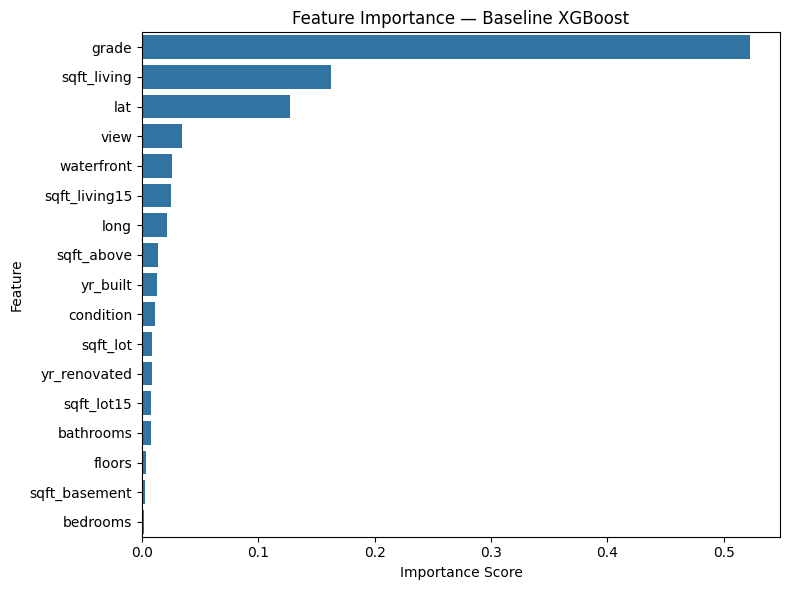

In [14]:
# feature importance

importance_df = pd.DataFrame({
    "feature": tabular_features,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

# Tabular view
display(importance_df)

# Bar plot
plt.figure(figsize=(8, 6))
sns.barplot(
    data=importance_df,
    x="importance",
    y="feature"
)
plt.title("Feature Importance — Baseline XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## Image-only model

In [15]:
# Load fused dataset (contains image embeddings)
train_mm = pd.read_csv("/kaggle/working/fuseddataset/train_mm.csv")

img_cols = [str(i) for i in range(512)]

X_img = train_mm[img_cols].values
y = np.log1p(train_mm["price"].values)

pca = PCA(n_components=50, random_state=42)
X_img = pca.fit_transform(X_img)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_img, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_tr)
X_val = scaler.transform(X_val)

model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=5,
    gamma=0.1,
    subsample=0.75,
    colsample_bytree=0.75,
    reg_alpha=0.1,
    reg_lambda=1.5,
    tree_method="hist",
    random_state=42
)

model.fit(X_tr, y_tr)

val_preds = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, val_preds))
r2   = r2_score(y_val, val_preds)

print(f"Image-only RMSE (log): {rmse:.4f}")
print(f"Image-only R²: {r2:.4f}")


Image-only RMSE (log): 0.4314
Image-only R²: 0.3256


## Hybrid-model

In [16]:
# Load fused datasets
train_mm = pd.read_csv("/kaggle/working/fuseddataset/train_mm.csv")
test_mm  = pd.read_csv("/kaggle/working/fuseddataset/test_mm.csv")

tabular_features = [
    'bedrooms','bathrooms','sqft_living','sqft_lot','floors',
    'waterfront','view','condition','grade',
    'sqft_above','sqft_basement',
    'yr_built','yr_renovated',
    'lat','long',
    'sqft_living15','sqft_lot15'
]

img_cols = [str(i) for i in range(512)]

X_tab = train_mm[tabular_features].values
X_img = train_mm[img_cols].values
y = np.log1p(train_mm["price"].values)

pca = PCA(n_components=20, random_state=42)
X_img = pca.fit_transform(X_img)

X_tab_tr, X_tab_val, X_img_tr, X_img_val, y_tr, y_val = train_test_split(
    X_tab, X_img, y, test_size=0.2, random_state=42
)

sc_tab = StandardScaler()
sc_img = StandardScaler()

X_tab_tr = sc_tab.fit_transform(X_tab_tr)
X_tab_val = sc_tab.transform(X_tab_val)

X_img_tr = sc_img.fit_transform(X_img_tr)
X_img_val = sc_img.transform(X_img_val)

X_tr = np.hstack([X_tab_tr, X_img_tr])
X_val = np.hstack([X_tab_val, X_img_val])

model = XGBRegressor(
    n_estimators=900,
    learning_rate=0.03,
    max_depth=7,
    min_child_weight=5,
    gamma=0.1,
    subsample=0.75,
    colsample_bytree=0.75,
    reg_alpha=0.1,
    reg_lambda=1.5,
    tree_method="hist",
    random_state=42
)

model.fit(X_tr, y_tr)

val_preds = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, val_preds))
r2   = r2_score(y_val, val_preds)

print(f"Hybrid RMSE (log): {rmse:.4f}")
print(f"Hybrid R²: {r2:.4f}")



Hybrid RMSE (log): 0.1660
Hybrid R²: 0.9001


In [17]:
# ----- Generate predictions for fused test set -----

# Prepare test features using SAME preprocessing
X_tab_test = test_mm[tabular_features].values
X_img_test = test_mm[img_cols].values

X_img_test = pca.transform(X_img_test)

X_tab_test = sc_tab.transform(X_tab_test)
X_img_test = sc_img.transform(X_img_test)

X_test = np.hstack([X_tab_test, X_img_test])

# Predict
test_log_preds = model.predict(X_test)
test_price_preds = np.expm1(test_log_preds)

# Save CSV (same format as baseline)
submission = pd.DataFrame({
    "id": test_mm["id"],
    "predicted_price": test_price_preds
})

submission.to_csv("xgboost_fused_final.csv", index=False)
submission.head()


,id,predicted_price
0,2591820310,3.786051e+05
1,7974200820,8.468731e+05
2,7701450110,1.085940e+06
3,9522300010,1.893490e+06
4,9510861140,7.463784e+05


In [18]:

# GRAD-CAM

IMAGE_DIR = "/kaggle/input/downloadedimages/train"
OUTPUT_DIR = "/kaggle/working/gradcam_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc = torch.nn.Identity()
model = model.to(DEVICE)
model.eval()

target_layer = model.layer4[-1].conv2

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

activations, gradients = [], []

def forward_hook(module, input, output):
    activations.append(output)

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0])

target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

def generate_gradcam(img_path):
    activations.clear()
    gradients.clear()

    img = Image.open(img_path).convert("RGB")
    x = transform(img).unsqueeze(0).to(DEVICE)

    features = model(x)
    loss = features.mean()
    model.zero_grad()
    loss.backward()

    grads = gradients[0][0]
    acts = activations[0][0]

    weights = grads.mean(dim=(1, 2))
    cam = torch.sum(weights[:, None, None] * acts, dim=0)

    cam = F.relu(cam)
    cam -= cam.min()
    if cam.max() != 0:
      cam /= cam.max()

    cam = cam.detach().cpu().numpy()
    cam = cv2.resize(cam, (224, 224))


    return cam, img

sample_imgs = np.random.choice(
    [f for f in os.listdir(IMAGE_DIR) if f.endswith(".png")],
    size=100,
    replace=False
)

for fname in sample_imgs:
    cam, img = generate_gradcam(os.path.join(IMAGE_DIR, fname))

    img_np = np.array(img.resize((224, 224)))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(img_np, 0.6, heatmap, 0.4, 0)

    cv2.imwrite(
        os.path.join(OUTPUT_DIR, fname.replace(".png", "_gradcam.png")),
        cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)
    )

print(f"Saved Grad-CAM images to {OUTPUT_DIR}")



Saved Grad-CAM images to /kaggle/working/gradcam_outputs


In [19]:
ZIP_PATH = "/kaggle/working/gradcam_outputs.zip"

# Remove existing zip if present
if os.path.exists(ZIP_PATH):
    os.remove(ZIP_PATH)

# Create zip archive
shutil.make_archive(
    base_name=ZIP_PATH.replace(".zip", ""),
    format="zip",
    root_dir=OUTPUT_DIR
)

print(f"Zipped Grad-CAM images at: {ZIP_PATH}")


Zipped Grad-CAM images at: /kaggle/working/gradcam_outputs.zip


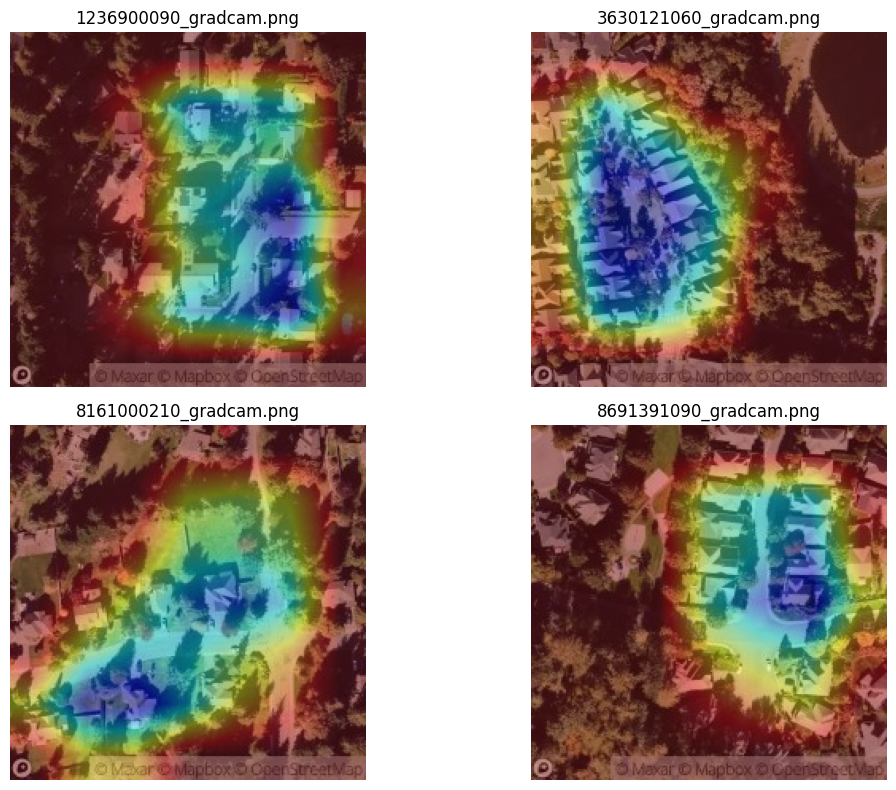

In [20]:
# ---------- Display Grad-CAM Samples ----------

OUTPUT_DIR = "/kaggle/working/gradcam_outputs"

sample_files = os.listdir(OUTPUT_DIR)[:4]

plt.figure(figsize=(12, 8))

for i, fname in enumerate(sample_files):
    img = cv2.imread(os.path.join(OUTPUT_DIR, fname))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.title(fname)
    plt.axis("off")

plt.tight_layout()
plt.show()
